In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import scipy as sp
import sophrosyne
import pandas as pd

In [2]:
import importlib
importlib.reload(sophrosyne)

<module 'sophrosyne' from '/home/rolando/Documents/Yachay/sophrosyne/sophrosyne/results/linz_sprott/sophrosyne.py'>

# Trajectories

In [58]:
N = 200
a = 0.53
epsilon = 0.1
t_span = (0, 10000)
dt = 0.01
# Time vector
t = np.arange(t_span[0], t_span[1], dt)
M = len(t)
print(M)
seed = None
mask = 2000

1000000


In [59]:
runner = sophrosyne.CoupledRunner(N=N, a=a, epsilon=epsilon, M=M, dt=dt, seed=seed, mask = mask)
s, t, z_m, x_m, y_m, avg_sigs, explode = runner.run()


    ╔══════════════════════════════════╗
    ║            SOPHROSYNE            ║
    ║            BETA v.0.2            ║
    ║   Coupled Linz-Sprott Dynamics   ║
    ║          by R.S.S.G.             ║
    ╚══════════════════════════════════╝
    
Calculating the time-averaged standard deviation...


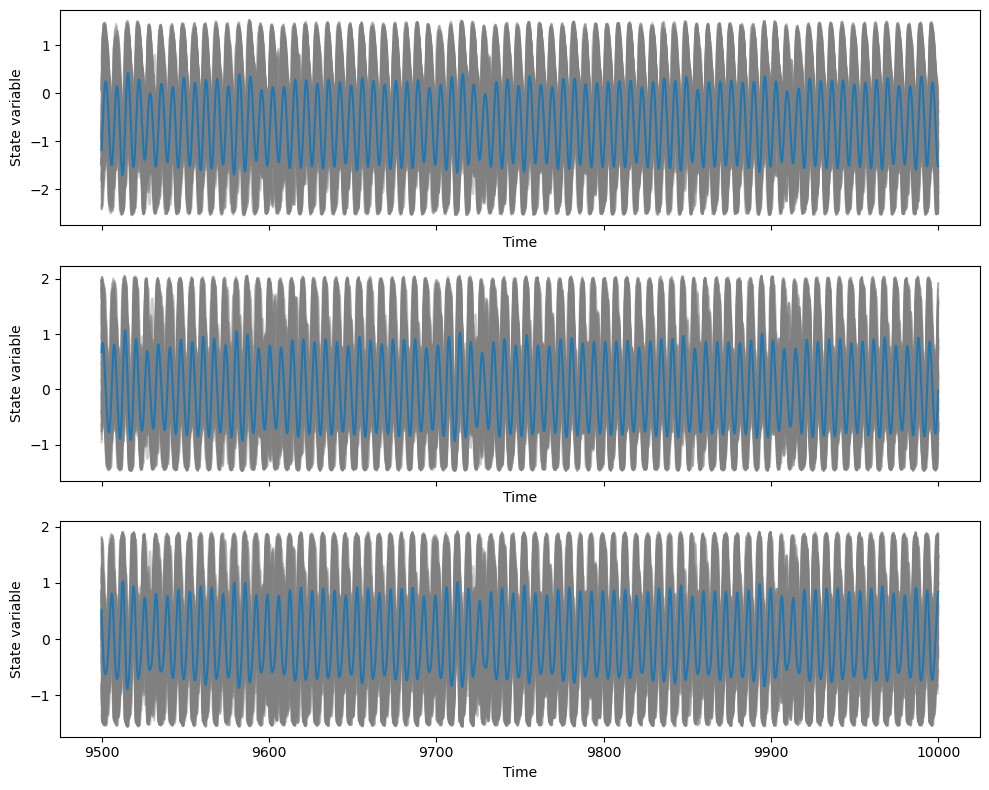

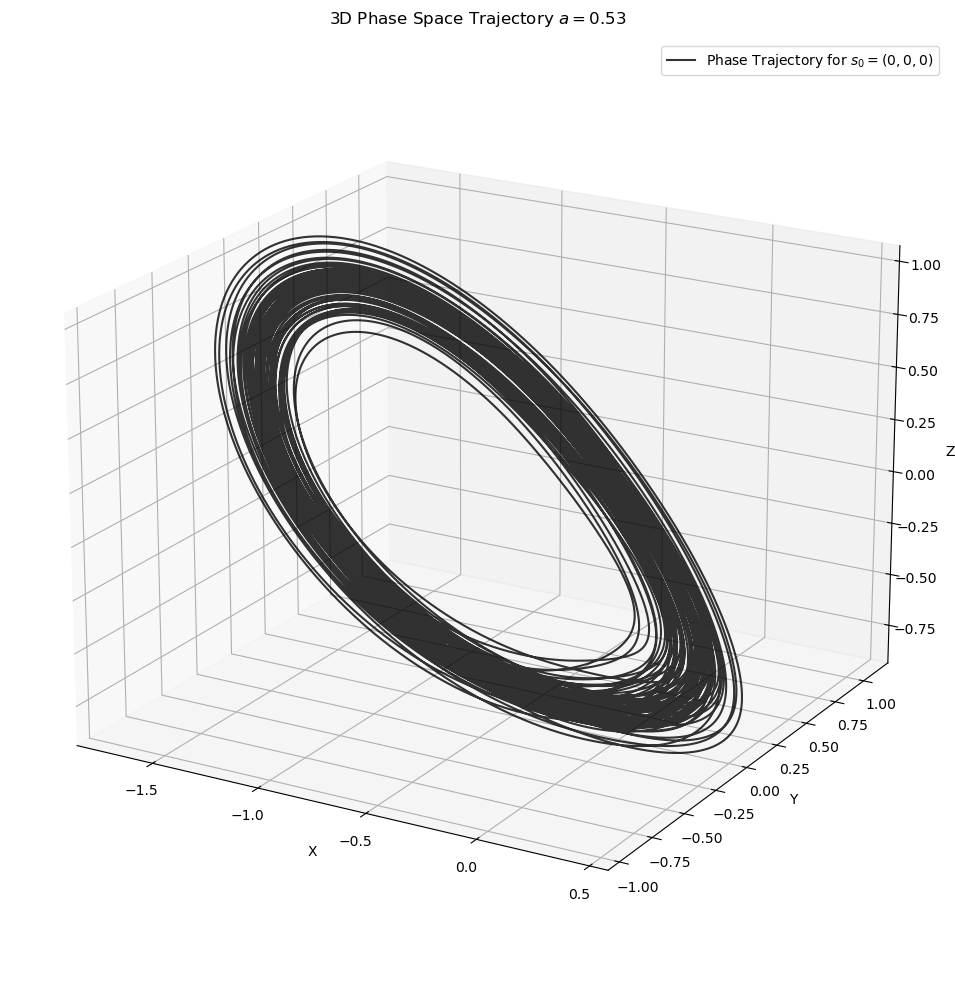

In [60]:
mask = int(0.05*(len(t)))
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i in range(100):
    ax[0].plot(t[-mask:], s[:, i, 0][-mask:], c="gray", alpha=0.4)
    ax[1].plot(t[-mask:], s[:, i, 1][-mask:], c="gray", alpha=0.4)
    ax[2].plot(t[-mask:], s[:, i, 2][-mask:], c="gray", alpha=0.4)
ax[0].plot(t[-mask:], x_m[-mask:])
ax[1].plot(t[-mask:], y_m[-mask:])
ax[2].plot(t[-mask:], z_m[-mask:])
for i in range(3):
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('State variable')
plt.tight_layout()
#plt.xlim(108,109)
plt.show()

fig = plt.figure(figsize=(10, 10))
fig.suptitle(fr"3D Phase Space Trajectory $a={a}$")
ax = fig.add_subplot(projection='3d')
ax.plot(x_m[-mask:], y_m[-mask:], z_m[-mask:], label=fr'Phase Trajectory for $s_0 = (0,0,0)$',c='k', linestyle = "-", alpha=0.8)
#ax.plot(s[:, 1, 0][-mask:], s[:, 1, 1][-mask:], s[:, 1, 2][-mask:], label=fr'Phase Trajectory for $s_0 = (0,0,0)$',c='k', linestyle = "-", alpha=0.8)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.tight_layout()
ax.view_init(elev=20, azim=-60)

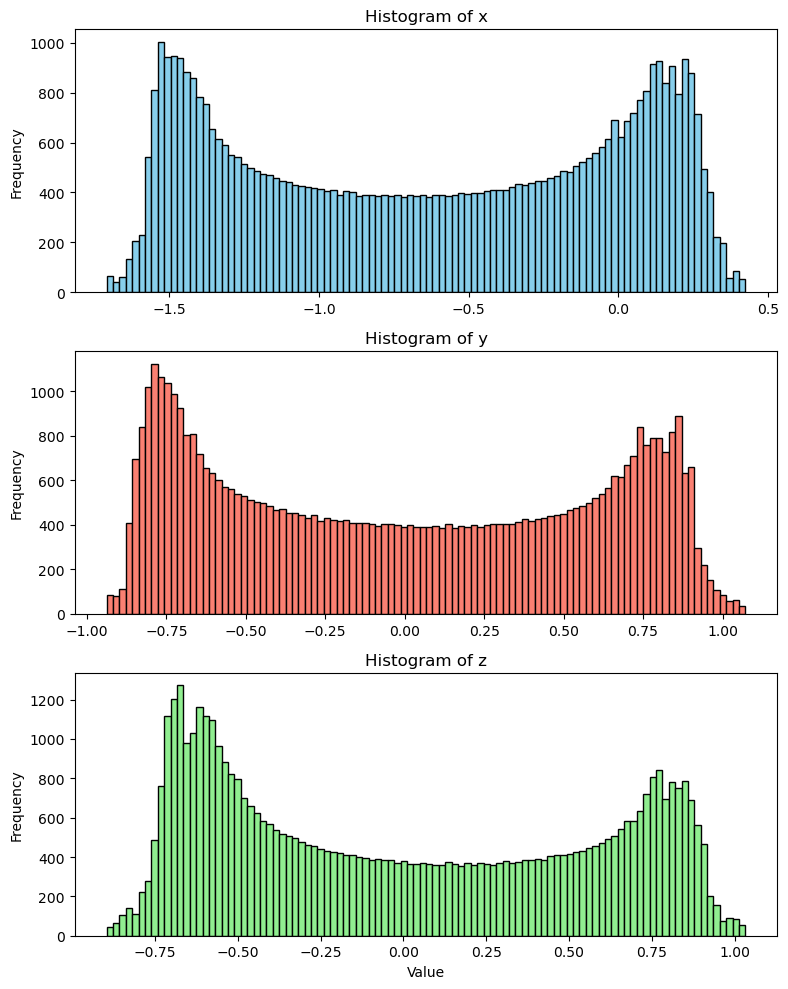

In [61]:
# Create subplots: 3 rows, 1 column
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=False)

# Histogram for x
axes[0].hist(x_m[-mask:], bins=100, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of x')

# Histogram for y
axes[1].hist(y_m[-mask:], bins=100, color='salmon', edgecolor='black')
axes[1].set_title('Histogram of y')

# Histogram for z
axes[2].hist(z_m[-mask:], bins=100, color='lightgreen', edgecolor='black')
axes[2].set_title('Histogram of z')

# Add labels
for ax in axes:
    ax.set_ylabel('Frequency')

axes[2].set_xlabel('Value')

plt.tight_layout()
plt.show()


In [62]:
print(s.shape, x_m.shape)

(1000000, 200, 3) (1000000,)


# Left Region

In [3]:
N = 200
a = 0.53
epsilon = 0.01
t_span = (0, 5000)
dt = 0.005
# Time vector
t = np.arange(t_span[0], t_span[1], dt)
M = len(t)
seed = None
mask = 2000

In [4]:
runner = sophrosyne.CoupledRunner(N=N, a=a, epsilon=epsilon, M=M, dt=dt, seed=seed, mask = mask)
s, t, z_m, x_m, y_m, avg_sigs, explode = runner.run()


    ╔══════════════════════════════════╗
    ║            SOPHROSYNE            ║
    ║            BETA v.0.2            ║
    ║   Coupled Linz-Sprott Dynamics   ║
    ║          by R.S.S.G.             ║
    ╚══════════════════════════════════╝
    
Escaped at iteration $n=5733$
200.303425939717 119.63949172036428 71.45414131801212
Calculating the time-averaged standard deviation...


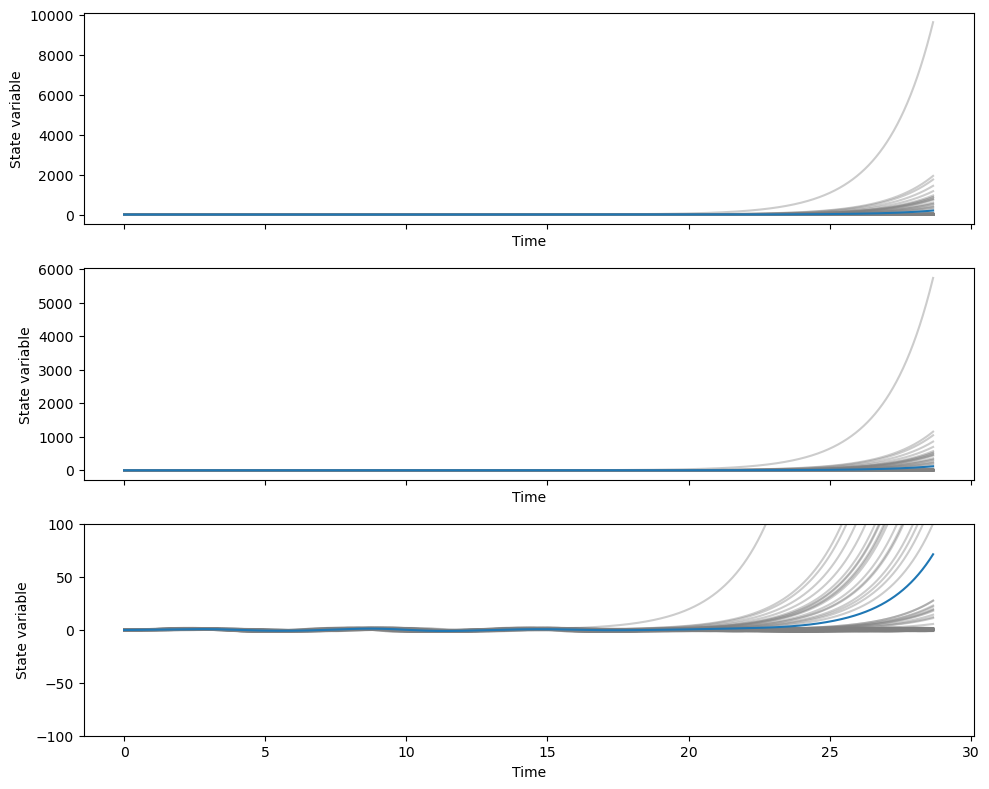

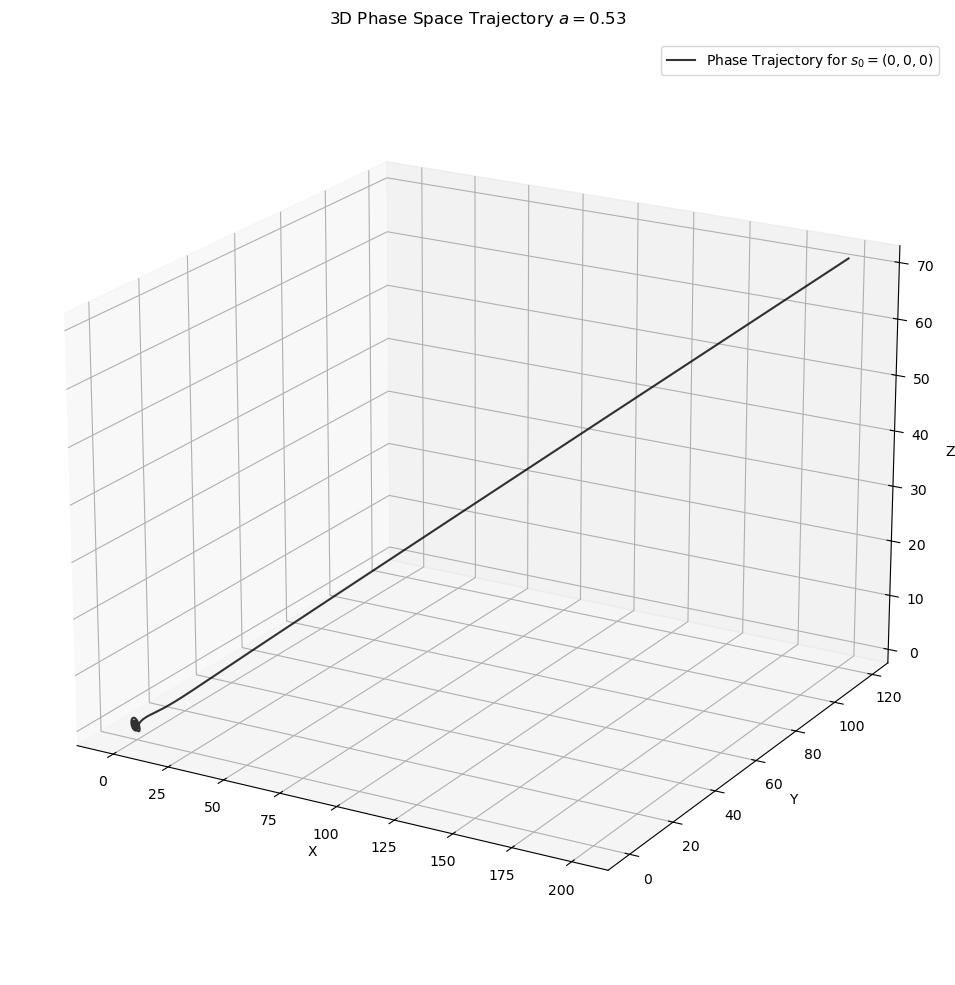

In [5]:
mask = int(1*(len(t)))
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i in range(100):
    ax[0].plot(t[-mask:], s[:, i, 0][-mask:], c="gray", alpha=0.4)
    ax[1].plot(t[-mask:], s[:, i, 1][-mask:], c="gray", alpha=0.4)
    ax[2].plot(t[-mask:], s[:, i, 2][-mask:], c="gray", alpha=0.4)
ax[0].plot(t[-mask:], x_m[-mask:])
ax[1].plot(t[-mask:], y_m[-mask:])
ax[2].plot(t[-mask:], z_m[-mask:])
for i in range(3):
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('State variable')
plt.tight_layout()
plt.ylim(-100,100)
plt.show()

fig = plt.figure(figsize=(10, 10))
fig.suptitle(fr"3D Phase Space Trajectory $a={a}$")
ax = fig.add_subplot(projection='3d')
ax.plot(x_m[-mask:], y_m[-mask:], z_m[-mask:], label=fr'Phase Trajectory for $s_0 = (0,0,0)$',c='k', linestyle = "-", alpha=0.8)
#ax.plot(s[:, 1, 0][-mask:], s[:, 1, 1][-mask:], s[:, 1, 2][-mask:], label=fr'Phase Trajectory for $s_0 = (0,0,0)$',c='k', linestyle = "-", alpha=0.8)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.tight_layout()
ax.view_init(elev=20, azim=-60)

In [6]:
cond = (
    (s[:, :, 0] - x_m[:, None] <= 20) &
    (s[:, :, 1] - y_m[:, None] <= 20) &
    (s[:, :, 2] - z_m[:, None] <= 20)
)

# Now apply the mask to s[:,:,0]
s_masked = np.where(cond[:,:, None], s, np.nan)

# Compute row-wise mean ignoring NaNs
new_mean = np.nanmean(s_masked, axis=1)

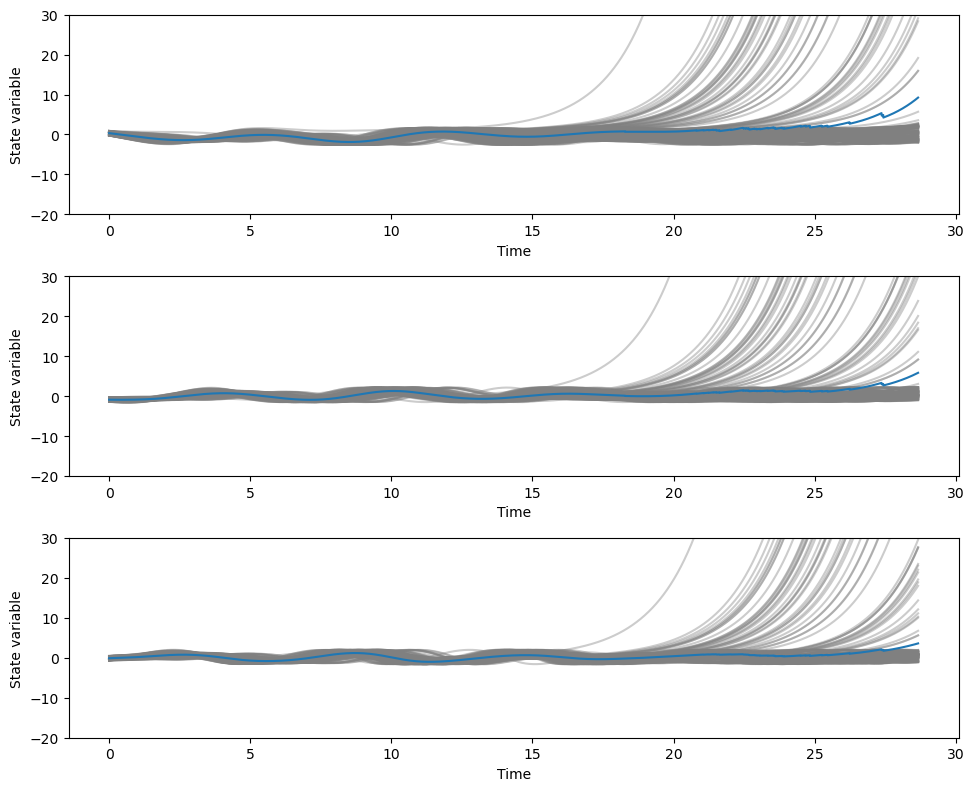

In [7]:
ask = int(1*(len(t)))
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharey=True)
for i in range(200):
    ax[0].plot(t[-mask:], s[:, i, 0][-mask:], c="gray", alpha=0.4)
    ax[1].plot(t[-mask:], s[:, i, 1][-mask:], c="gray", alpha=0.4)
    ax[2].plot(t[-mask:], s[:, i, 2][-mask:], c="gray", alpha=0.4)
ax[0].plot(t[-mask:], new_mean[:,0][-mask:])
ax[1].plot(t[-mask:], new_mean[:,1][-mask:])
ax[2].plot(t[-mask:], new_mean[:,2][-mask:])
for i in range(3):
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('State variable')
plt.tight_layout()
plt.ylim(-20,30)
plt.show()

# Right Region

In [8]:
N = 200
a = 0.53
epsilon = 0.6
t_span = (0, 5000)
dt = 0.005
# Time vector
t = np.arange(t_span[0], t_span[1], dt)
M = len(t)
seed = None
mask = 2000

In [9]:
runner = sophrosyne.CoupledRunner(N=N, a=a, epsilon=epsilon, M=M, dt=dt, seed=seed, mask = mask)
s, t, z_m, x_m, y_m, avg_sigs, explode = runner.run()


    ╔══════════════════════════════════╗
    ║            SOPHROSYNE            ║
    ║            BETA v.0.2            ║
    ║   Coupled Linz-Sprott Dynamics   ║
    ║          by R.S.S.G.             ║
    ╚══════════════════════════════════╝
    
Escaped at iteration $n=6946$
200.03449182143652 118.93070296299807 71.00121949323652
Calculating the time-averaged standard deviation...


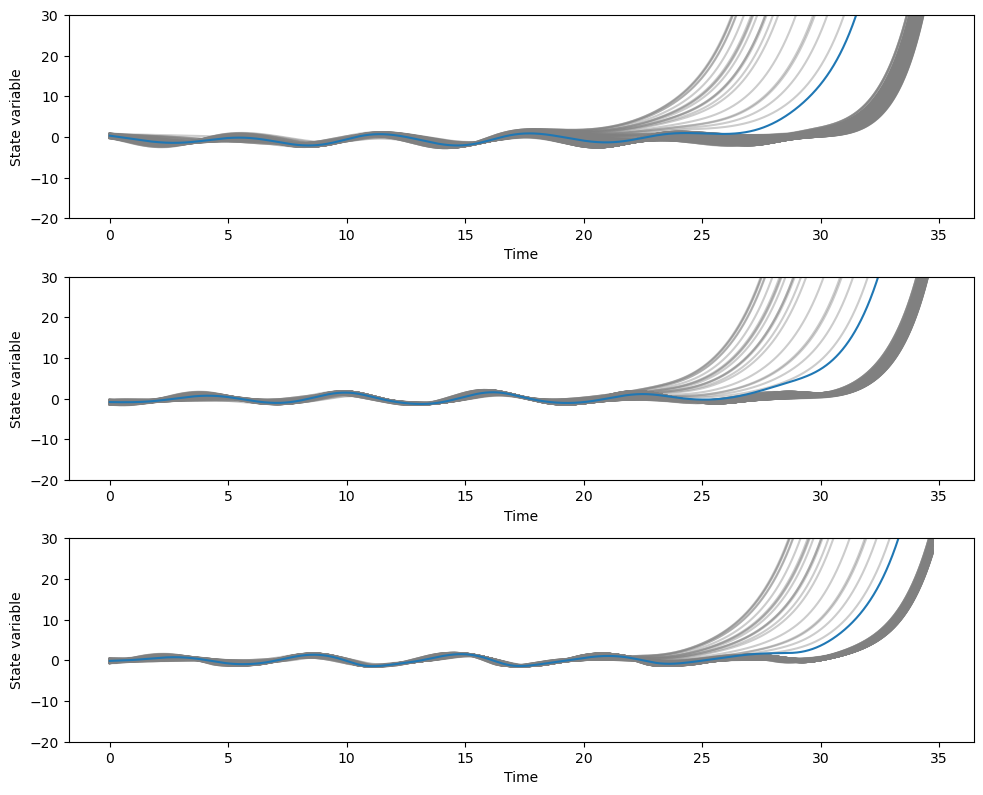

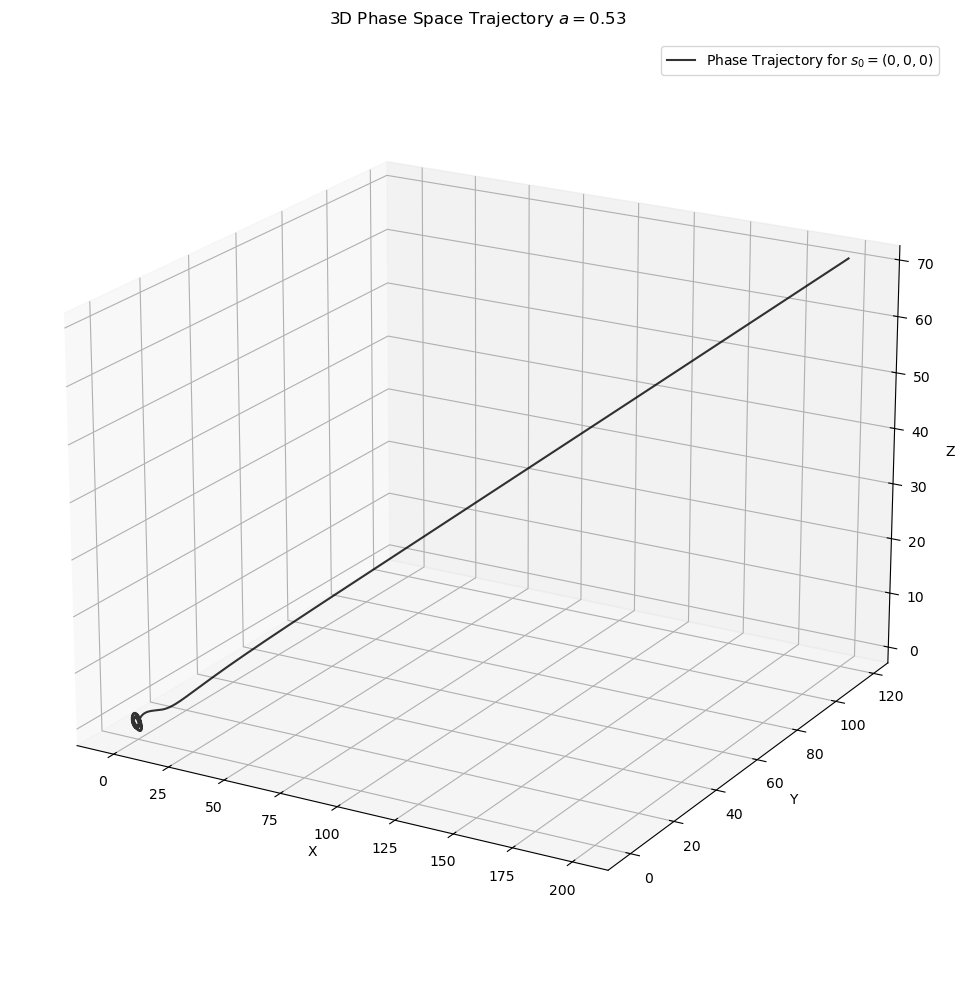

In [10]:
mask = int(1*(len(t)))
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharey=True)
for i in range(200):
    ax[0].plot(t[-mask:], s[:, i, 0][-mask:], c="gray", alpha=0.4)
    ax[1].plot(t[-mask:], s[:, i, 1][-mask:], c="gray", alpha=0.4)
    ax[2].plot(t[-mask:], s[:, i, 2][-mask:], c="gray", alpha=0.4)
ax[0].plot(t[-mask:], x_m[-mask:])
ax[1].plot(t[-mask:], y_m[-mask:])
ax[2].plot(t[-mask:], z_m[-mask:])
for i in range(3):
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('State variable')
plt.tight_layout()
plt.ylim(-20,30)
plt.show()

fig = plt.figure(figsize=(10, 10))
fig.suptitle(fr"3D Phase Space Trajectory $a={a}$")
ax = fig.add_subplot(projection='3d')
ax.plot(x_m[-mask:], y_m[-mask:], z_m[-mask:], label=fr'Phase Trajectory for $s_0 = (0,0,0)$',c='k', linestyle = "-", alpha=0.8)
#ax.plot(s[:, 1, 0][-mask:], s[:, 1, 1][-mask:], s[:, 1, 2][-mask:], label=fr'Phase Trajectory for $s_0 = (0,0,0)$',c='k', linestyle = "-", alpha=0.8)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.tight_layout()
ax.view_init(elev=20, azim=-60)

In [11]:
cond = (
    (s[:, :, 0] - x_m[:, None] <= 20) &
    (s[:, :, 1] - y_m[:, None] <= 20) &
    (s[:, :, 2] - z_m[:, None] <= 20)
)

# Now apply the mask to s[:,:,0]
s_masked = np.where(cond[:,:, None], s, np.nan)

# Compute row-wise mean ignoring NaNs
new_mean = np.nanmean(s_masked, axis=1)

In [12]:
np.mean(np.nanstd(s_masked, axis=1)[-int(0.1*len(new_mean)):], axis=0)

array([3.95582751, 2.10508988, 1.12147886])

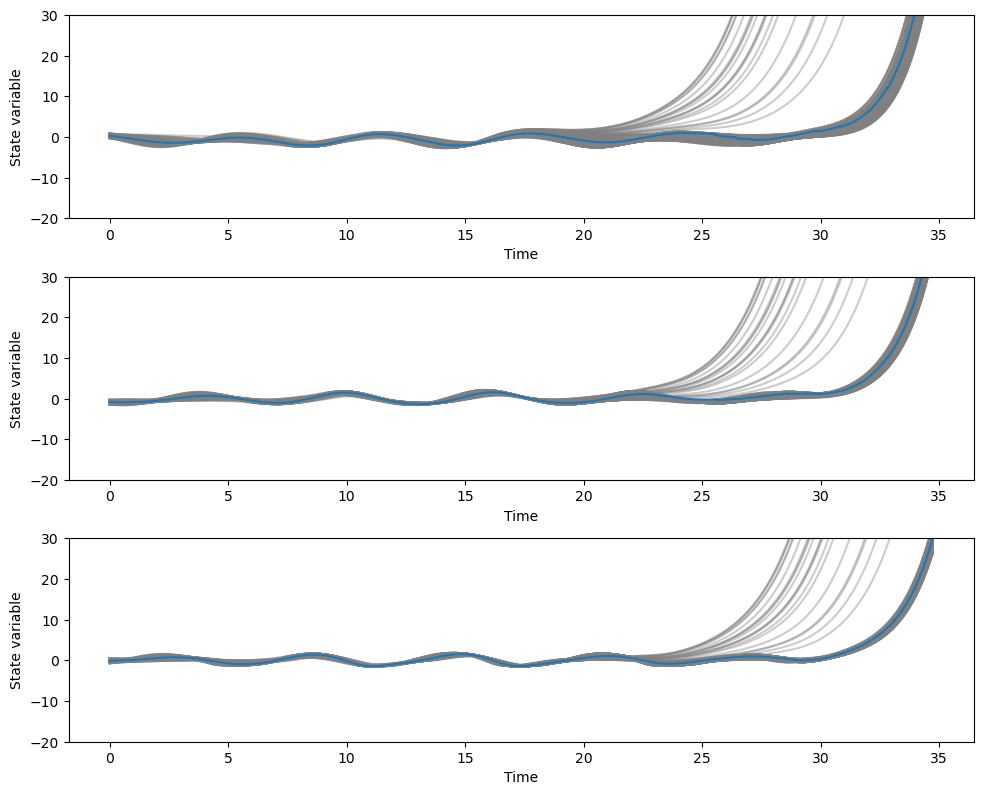

In [13]:
mask = int(1*(len(t)))
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharey=True)
for i in range(200):
    ax[0].plot(t[-mask:], s[:, i, 0][-mask:], c="gray", alpha=0.4)
    ax[1].plot(t[-mask:], s[:, i, 1][-mask:], c="gray", alpha=0.4)
    ax[2].plot(t[-mask:], s[:, i, 2][-mask:], c="gray", alpha=0.4)
ax[0].plot(t[-mask:], new_mean[:,0][-mask:])
ax[1].plot(t[-mask:], new_mean[:,1][-mask:])
ax[2].plot(t[-mask:], new_mean[:,2][-mask:])
for i in range(3):
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('State variable')
plt.tight_layout()
plt.ylim(-20,30)
plt.show()

# STD plots

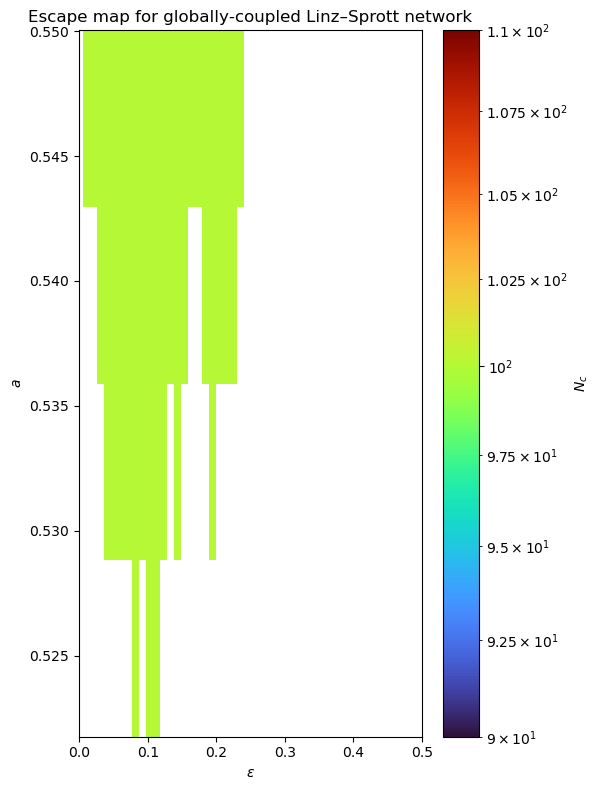

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def plot_escape_diagram(
        csv_path: str,
        *,
        cmap: str = "turbo",          # perceptually‑uniform rainbow
        agg: str = "min",             # how to combine repeated (ε,a) points
        use_log: bool = True
    ):
    """
    Parameters
    ----------
    csv_path : str
        Path to a CSV with columns  a, N, epsilon, escaped.
    cmap     : str
        Any Matplotlib colormap for the colour scale.
    agg      : {'min','max','mean','median'}
        How to aggregate the N column when several rows share the same (ε,a).
    use_log  : bool
        Draw colour bar on a log scale (recommended when N spans orders of magnitude).
    """
    df = pd.read_csv(csv_path)

    # --- keep only the runs that actually escaped ----------------------------
    esc = df[~df["escaped"].astype(bool)]

    # --- build a regular (ε,a) grid; pivot gives us an *array* of N_c
    pivot = esc.pivot_table(index="a", columns="epsilon",
                            values="N", aggfunc=agg)

    # epsilon and a tick coordinates
    eps = pivot.columns.to_numpy(float)
    a    = pivot.index.to_numpy(float)
    E, A = np.meshgrid(eps, a)        # for pcolormesh

    # -------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 8))

    pcm = ax.pcolormesh(
        E, A, pivot.values,
        shading="auto",
        cmap=cmap,
        norm=LogNorm() if use_log else None
    )
    fig.colorbar(pcm, ax=ax, label=r"$N_c$")

    # --- cosmetic stuff -------------------------------------------------------
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$a$")
    ax.set_xlim(0, 0.5)
    #ax.set_ylim(0.2, a.max())
    ax.set_title("Escape map for globally‑coupled Linz–Sprott network")

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# example call
plot_escape_diagram("cedia_results/std.csv", agg="min")


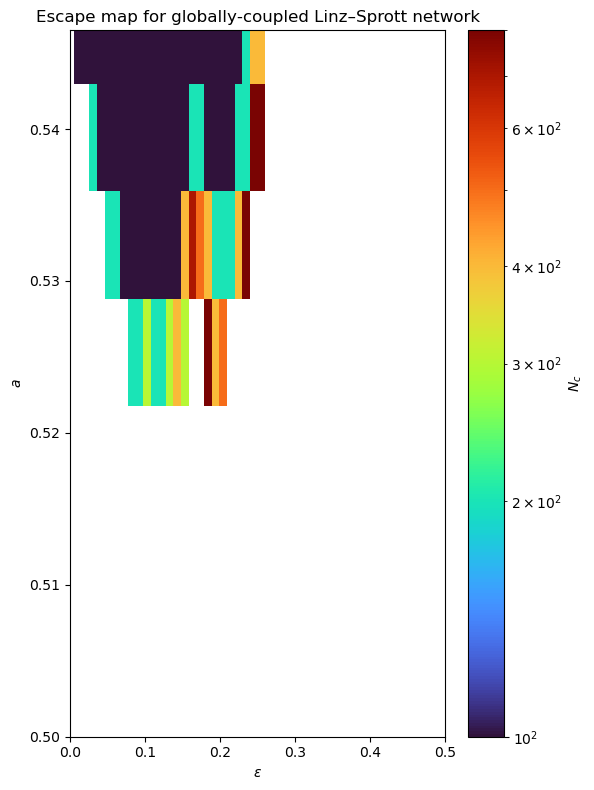

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def plot_escape_diagram(
        csv_path: str,
        *,
        cmap: str = "turbo",          # perceptually‑uniform rainbow
        agg: str = "min",             # how to combine repeated (ε,a) points
        use_log: bool = True
    ):
    """
    Parameters
    ----------
    csv_path : str
        Path to a CSV with columns  a, N, epsilon, escaped.
    cmap     : str
        Any Matplotlib colormap for the colour scale.
    agg      : {'min','max','mean','median'}
        How to aggregate the N column when several rows share the same (ε,a).
    use_log  : bool
        Draw colour bar on a log scale (recommended when N spans orders of magnitude).
    """
    df = pd.read_csv(csv_path)

    # --- keep only the runs that actually escaped ----------------------------
    esc = df[~df["escaped"].astype(bool)]

    # --- build a regular (ε,a) grid; pivot gives us an *array* of N_c
    pivot = esc.pivot_table(index="a", columns="epsilon",
                            values="N", aggfunc=agg)

    # epsilon and a tick coordinates
    eps = pivot.columns.to_numpy(float)
    a    = pivot.index.to_numpy(float)
    E, A = np.meshgrid(eps, a)        # for pcolormesh

    # -------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 8))

    pcm = ax.pcolormesh(
        E, A, pivot.values,
        shading="auto",
        cmap=cmap,
        norm=LogNorm() if use_log else None
    )
    fig.colorbar(pcm, ax=ax, label=r"$N_c$")

    # --- cosmetic stuff -------------------------------------------------------
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$a$")
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0.5, a.max())
    #ax.set_ylim(0.2, a.max())
    ax.set_title("Escape map for globally‑coupled Linz–Sprott network")

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# example call
plot_escape_diagram("cedia_results/large_total/std.csv", agg="min")

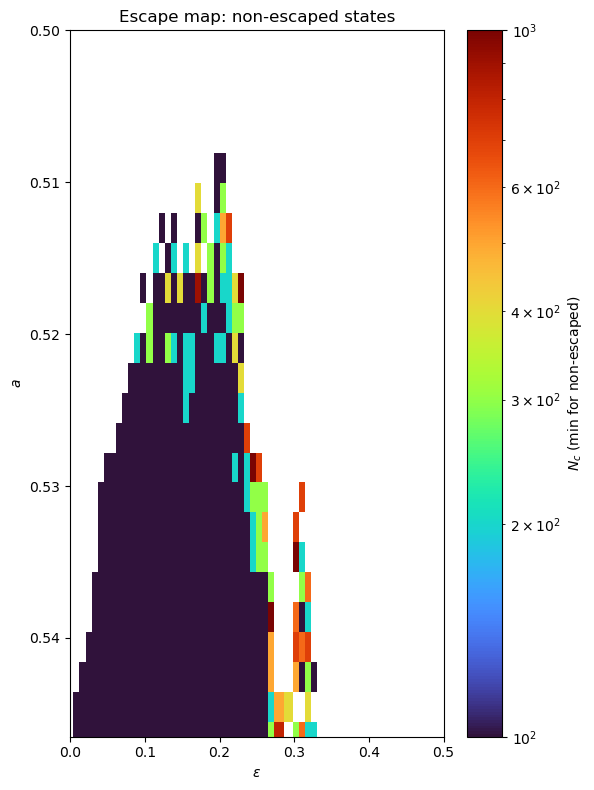

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def plot_non_escaped_min_N(
        csv_path: str,
        *,
        cmap: str = "turbo",
        use_log: bool = True
    ):
    """
    Plot the minimum N for non-escaped states as a function of (epsilon, a)

    Parameters
    ----------
    csv_path : str
        Path to CSV file with columns: N, a, epsilon, escaped, simulation
    cmap : str
        Matplotlib colormap
    use_log : bool
        Whether to use logarithmic color scale
    """
    df = pd.read_csv(csv_path)

    # Filter only the non-escaped states
    non_escaped = df[~df["escaped"].astype(bool)]

    # Group by (epsilon, a) and get the minimum N for each pair
    grouped = non_escaped.groupby(["epsilon", "a"])["N"].min().reset_index()

    # Pivot into 2D grid for plotting
    pivot = grouped.pivot(index="a", columns="epsilon", values="N")

    # Meshgrid for pcolormesh
    eps = pivot.columns.to_numpy(float)
    a = pivot.index.to_numpy(float)
    E, A = np.meshgrid(eps, a)

    # Replace zeros with nan to avoid log errors
    Z = pivot.values
    Z[Z <= 0] = np.nan

    # Plotting
    fig, ax = plt.subplots(figsize=(6, 8))

    pcm = ax.pcolormesh(
        E, A, Z,
        shading="auto",
        cmap=cmap,
        norm=LogNorm() if use_log else None
    )
    fig.colorbar(pcm, ax=ax, label=r"$N_c$ (min for non-escaped)")

    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$a$")
    ax.set_xlim(0, 0.5)
    ax.set_ylim(a.max(), 0.5)
    #ax.set_ylim(0.5, a.max())
    ax.set_title("Escape map: non-escaped states")

    plt.tight_layout()
    plt.show()


# Example usage:
plot_non_escaped_min_N("cedia_results/large_total_2/escaped.csv")

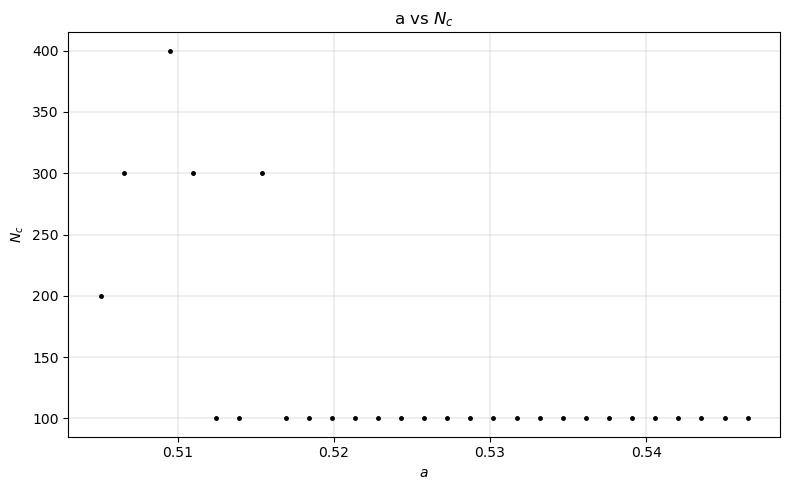

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_a_vs_Nc(csv_path: str, epsilon_filter=None):
    """
    Gráfico de a vs N_c (mínimo N para simulaciones no escapadas).

    Parámetros
    ----------
    csv_path : str
        Ruta al archivo CSV que contiene las columnas: N, a, epsilon, escaped, simulation
    epsilon_filter : float, opcional
        Si se proporciona, se filtrará por ese valor de epsilon
    """
    df = pd.read_csv(csv_path)

    # Filtrar por epsilon si se solicita
    if epsilon_filter is not None:
        df = df[df["epsilon"] == epsilon_filter]

    # Filtrar solo simulaciones que no escaparon
    non_escaped = df[~df["escaped"].astype(bool)]

    if non_escaped.empty:
        print("No hay datos de simulaciones no escapadas.")
        return

    # Agrupar por a y obtener el mínimo N
    grouped = non_escaped.groupby("a")["N"].min().reset_index()

    # Graficar
    plt.figure(figsize=(8, 5))
    plt.plot(grouped["a"], grouped["N"], ".", color="black", markersize=5)
    plt.xlabel(r"$a$")
    plt.ylabel(r"$N_c$")
    plt.title("a vs $N_c$")
    plt.grid(True, linewidth=0.3)
    plt.tight_layout()
    plt.show()

# Ejemplo de uso:
plot_a_vs_Nc("test_N_a/escaped.csv", epsilon_filter=0.2)

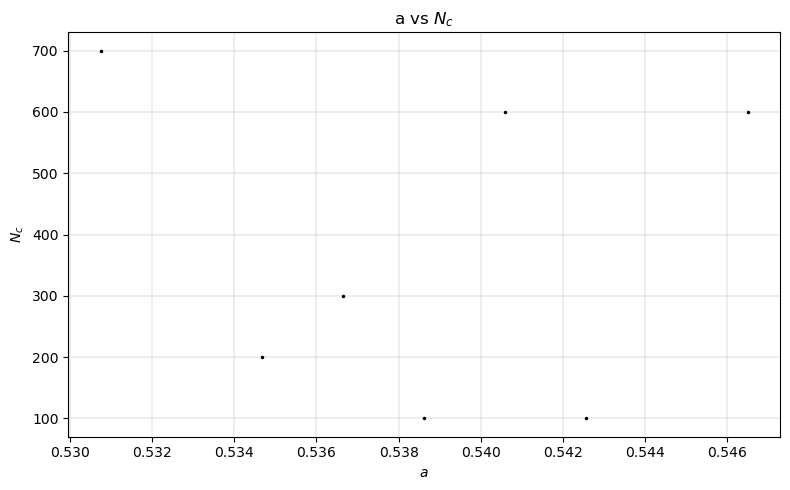

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_a_vs_Nc(csv_path: str, epsilon_filter=None):
    """
    Gráfico de a vs N_c (mínimo N para simulaciones no escapadas).

    Parámetros
    ----------
    csv_path : str
        Ruta al archivo CSV que contiene las columnas: N, a, epsilon, escaped, simulation
    epsilon_filter : float, opcional
        Si se proporciona, se filtrará por ese valor de epsilon
    """
    df = pd.read_csv(csv_path)

    # Filtrar por epsilon si se solicita
    if epsilon_filter is not None:
        df = df[df["epsilon"] == epsilon_filter]

    # Filtrar solo simulaciones que no escaparon
    non_escaped = df[~df["escaped"].astype(bool)]

    if non_escaped.empty:
        print("No hay datos de simulaciones no escapadas.")
        return

    # Agrupar por a y obtener el mínimo N
    grouped = non_escaped.groupby("a")["N"].min().reset_index()

    # Graficar
    plt.figure(figsize=(8, 5))
    plt.plot(grouped["a"], grouped["N"], ".", color="black", markersize=3)
    plt.xlabel(r"$a$")
    plt.ylabel(r"$N_c$")
    plt.title("a vs $N_c$")
    plt.grid(True, linewidth=0.3)
    plt.tight_layout()
    plt.show()

# Ejemplo de uso:
plot_a_vs_Nc("cedia_results/large_total_2/escaped.csv", epsilon_filter=0.310204)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque


# ==============================
# RHS of coupled supersystem
# ==============================
def rhs(x, y, z, a, eps):
    z_mean = np.mean(z)

    dx = y
    dy = z
    dz = (-a*z - y + np.abs(x) - 1.0) + eps*(z_mean - z)

    return dx, dy, dz


# ==============================
# RK4 single step
# ==============================
def rk4_step(x, y, z, dt, a, eps):

    k1x,k1y,k1z = rhs(x,y,z,a,eps)

    k2x,k2y,k2z = rhs(
        x+0.5*dt*k1x,
        y+0.5*dt*k1y,
        z+0.5*dt*k1z,
        a,eps)

    k3x,k3y,k3z = rhs(
        x+0.5*dt*k2x,
        y+0.5*dt*k2y,
        z+0.5*dt*k2z,
        a,eps)

    k4x,k4y,k4z = rhs(
        x+dt*k3x,
        y+dt*k3y,
        z+dt*k3z,
        a,eps)

    x += dt/6*(k1x+2*k2x+2*k3x+k4x)
    y += dt/6*(k1y+2*k2y+2*k3y+k4y)
    z += dt/6*(k1z+2*k2z+2*k3z+k4z)

    return x,y,z


# ==============================
# Main simulation
# ==============================
def simulate_supersystem(
        N=20,
        a=0.8,
        eps=0.2,
        dt=0.01,
        steps=200000,
        threshold=10,
        window=800):

    rng = np.random.default_rng()

    x = rng.normal(0,0.1,N)
    y = rng.normal(0,0.1,N)
    z = rng.normal(0,0.1,N)

    # Rolling buffers
    buf_x = deque(maxlen=window)
    buf_y = deque(maxlen=window)
    buf_z = deque(maxlen=window)
    buf_m = deque(maxlen=window)

    exploded=False
    info=None

    for t in range(steps):

        x,y,z = rk4_step(x,y,z,dt,a,eps)

        mx,my,mz = np.mean(x),np.mean(y),np.mean(z)

        buf_x.append(x.copy())
        buf_y.append(y.copy())
        buf_z.append(z.copy())
        buf_m.append([mx,my,mz])

        # -------- detection ----------
        mask = (
            (np.abs(x)>threshold) |
            (np.abs(y)>threshold) |
            (np.abs(z)>threshold)
        )

        if np.any(mask):
            exploded=True
            info=("element", np.where(mask)[0], t)
            break

        if max(abs(mx),abs(my),abs(mz)) > threshold:
            exploded=True
            info=("mean", None, t)
            break

    print("\n===== RESULT =====")
    print("Exploded:", exploded)
    print("Info:", info)

    # ================= Plot
    bx=np.array(buf_x)
    by=np.array(buf_y)
    bz=np.array(buf_z)
    bm=np.array(buf_m)

    t_axis=np.arange(len(bx))

    plt.figure()
    plt.plot(t_axis,bx)
    plt.plot(t_axis,bm[:,0])
    plt.title("Last window — x & mean")
    plt.show()

    plt.figure()
    plt.plot(t_axis,by)
    plt.plot(t_axis,bm[:,1])
    plt.title("Last window — y & mean")
    plt.show()

    plt.figure()
    plt.plot(t_axis,bz)
    plt.plot(t_axis,bm[:,2])
    plt.title("Last window — z & mean")
    plt.show()

Notice that as a>>ac, the sinchronization happens faster


===== RESULT =====
Exploded: False
Info: None


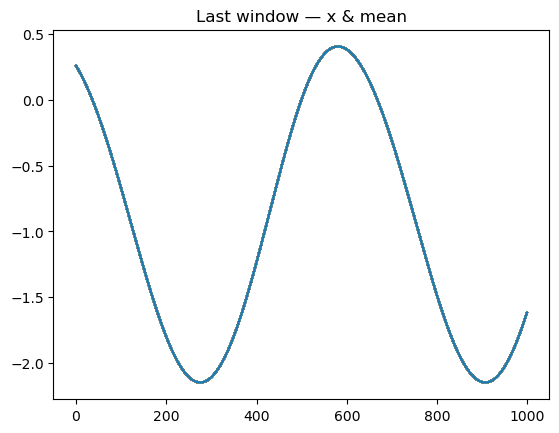

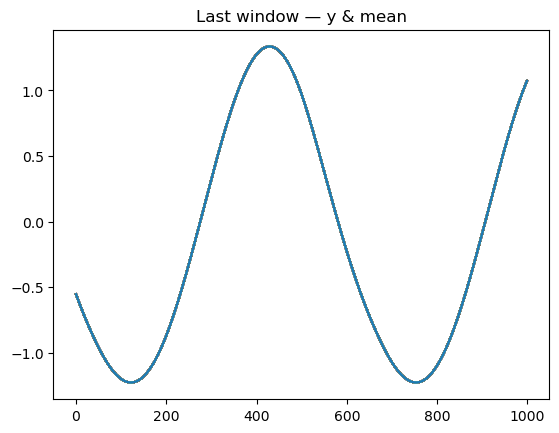

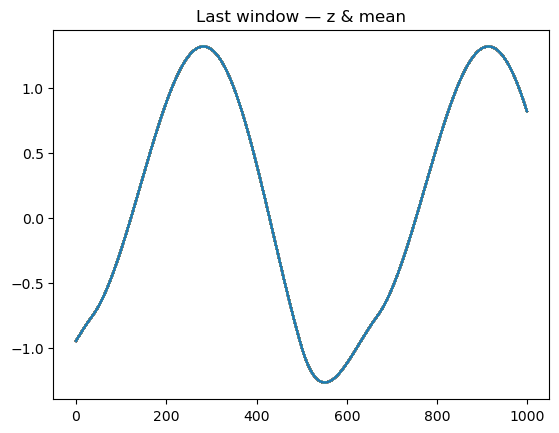

In [3]:
simulate_supersystem(N=100,
        a=0.8,
        eps=0.05,
        dt=0.01,
        steps=200000,
        threshold=10,
        window=1000)


===== RESULT =====
Exploded: False
Info: None


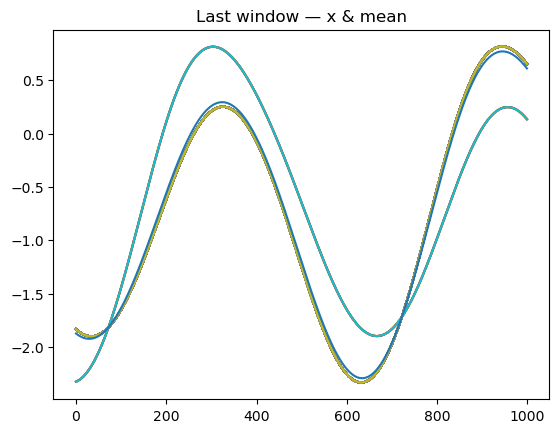

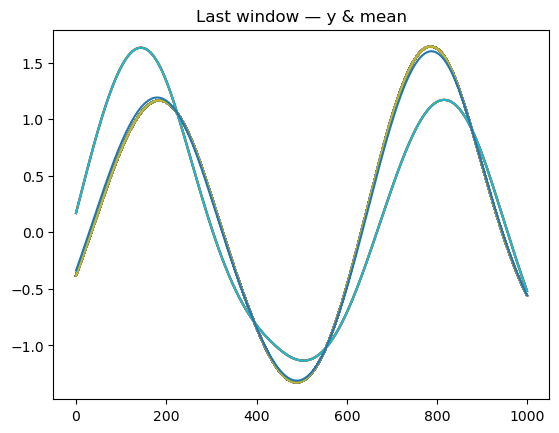

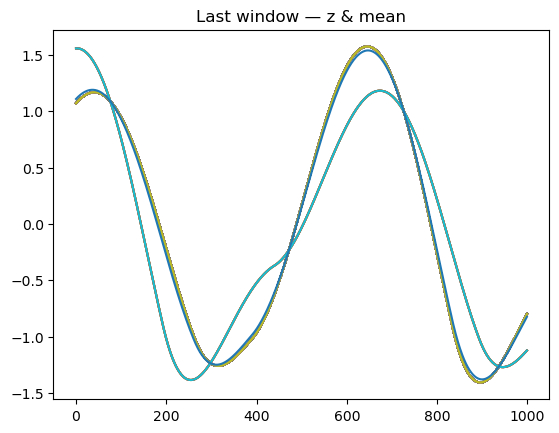

In [6]:
simulate_supersystem(N=100,
        a=0.7,
        eps=0.05,
        dt=0.01,
        steps=200000,
        threshold=10,
        window=1000)

In [11]:
simulate_supersystem(N=100,
        a=0.7,
        eps=0.05,
        dt=0.01,
        steps=10000000,
        threshold=10,
        window=1000)

KeyboardInterrupt: 


===== RESULT =====
Exploded: False
Info: None


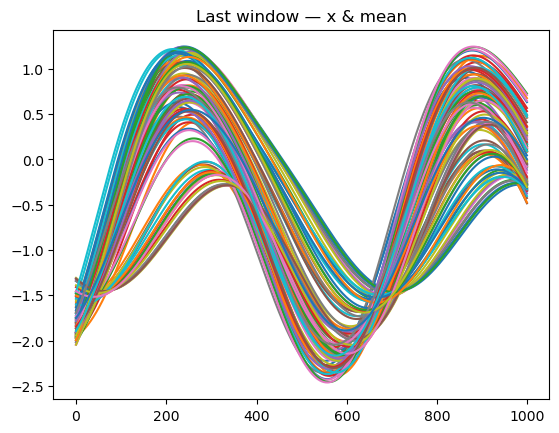

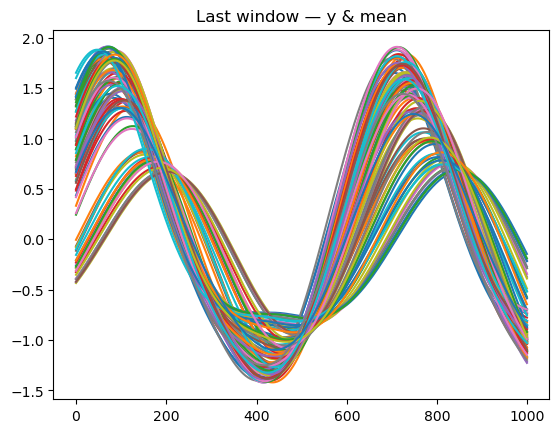

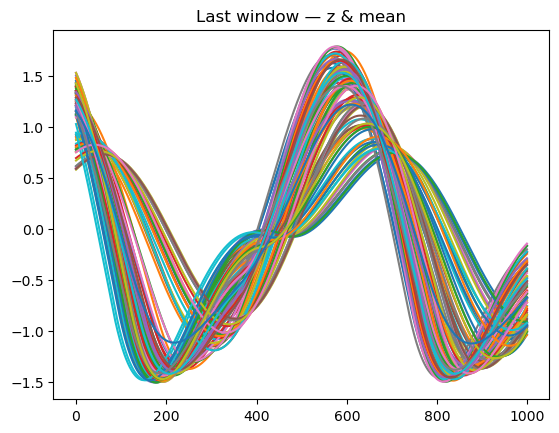

In [16]:
simulate_supersystem(N=100,
        a=0.6,
        eps=0.05,
        dt=0.01,
        steps=200000,
        threshold=10,
        window=1000)


===== RESULT =====
Exploded: False
Info: None


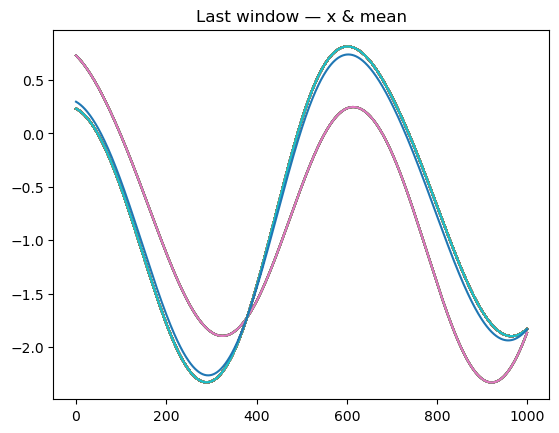

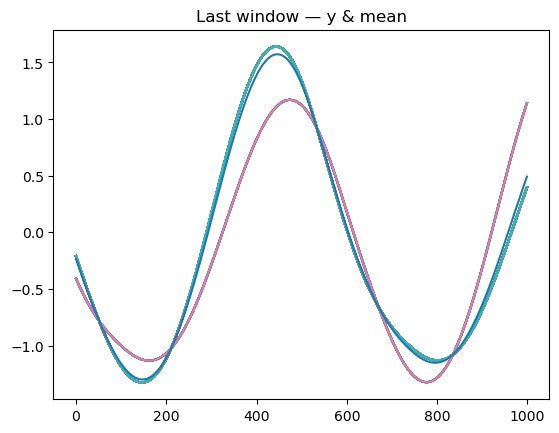

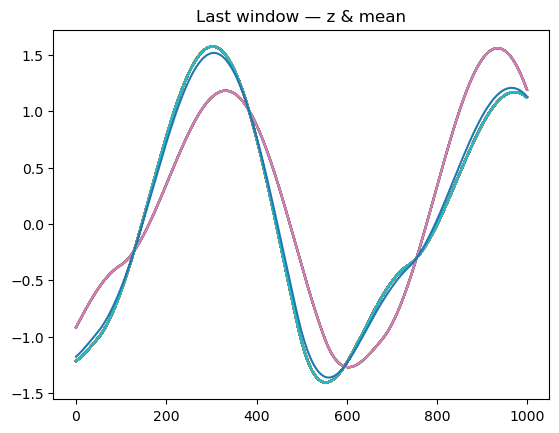

In [20]:
simulate_supersystem(N=100,
        a=0.7,
        eps=0.05,
        dt=0.01,
        steps=1000000,
        threshold=10,
        window=1000)


===== RESULT =====
Exploded: True
Info: ('element', array([62]), 82915)


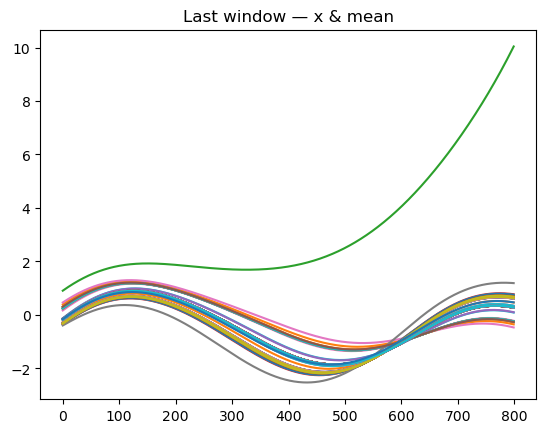

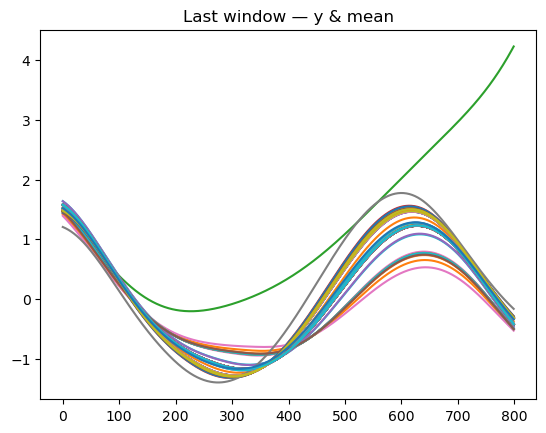

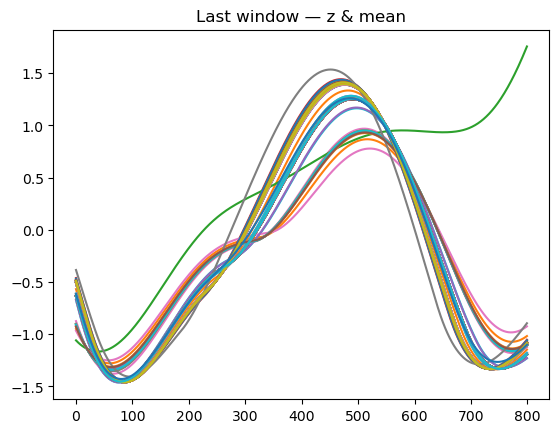

In [27]:
# Run
simulate_supersystem(N=100,
        a=0.6,
        eps=0.85,
        dt=0.01,
        steps=200000,
        threshold=10,
        window=800)



===== RESULT =====
Exploded: True
Info: ('element', array([20]), 2043)


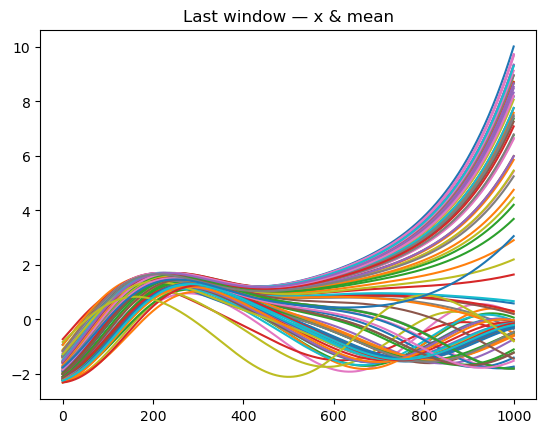

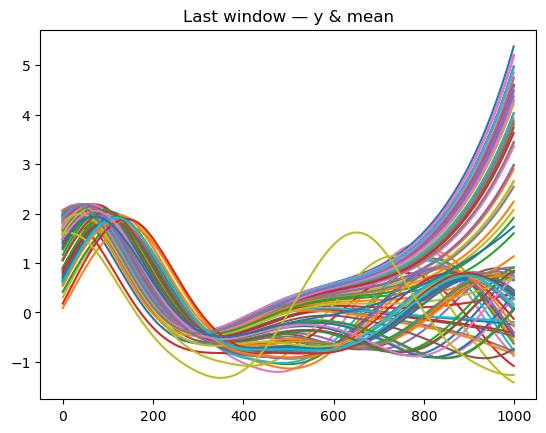

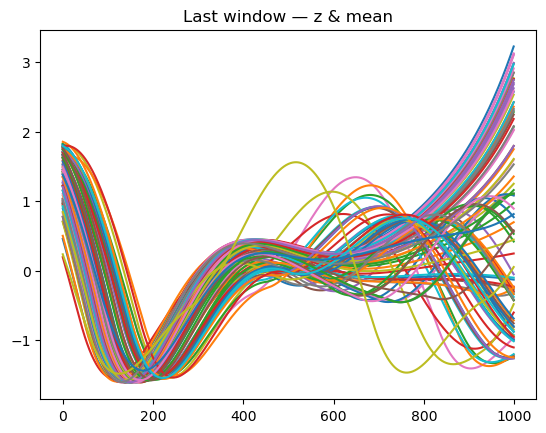

In [42]:
simulate_supersystem(N=100,
        a=0.533,
        eps=0.005,
        dt=0.01,
        steps=200000,
        threshold=10,
        window=1000)